# 🎯 Women's Representation in STEM Education — Linear Regression

**Mission:** To become a professional software developer and empower other women in programming by sharing knowledge and opening doors for them in the technology industry in Africa.

**Problem Statement:** Predict the **Female Graduation Rate (%)** in STEM fields based on enrollment, gender gap index, country, year, and STEM field. Understanding what drives graduation rates for women in STEM can help identify areas for targeted intervention and support.

**Dataset:** Women's Representation in Global STEM Education (Kaggle)

**Target Variable:** `Female Graduation Rate (%)`

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load & Explore the Dataset

In [2]:
df = pd.read_csv('women_in_stem.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (500, 6)


,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index
0,China,2018,20.4,43.2,Engineering,0.52
1,China,2005,35.6,29.3,Mathematics,0.98
2,China,2005,53.7,32.4,Biology,0.60
3,Germany,2007,65.0,63.6,Mathematics,0.69
4,Canada,2010,54.4,28.8,Engineering,0.74
5,India,2001,53.0,54.5,Computer Science,0.54
6,Canada,2002,69.0,23.2,Engineering,0.86
7,India,2000,29.5,38.1,Engineering,0.90
8,USA,2014,57.1,35.7,Biology,0.61
9,China,2020,36.7,64.3,Computer Science,0.96


In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     500 non-null    object 
 1   Year                        500 non-null    int64  
 2   Female Enrollment (%)       500 non-null    float64
 3   Female Graduation Rate (%)  500 non-null    float64
 4   STEM Fields                 500 non-null    object 
 5   Gender Gap Index            500 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 23.6+ KB

=== Statistical Summary ===


,Year,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
count,500.000000,500.000000,500.000000,500.000000
mean,2011.418000,43.939800,36.715200,0.745980
std,7.187112,14.316864,15.964231,0.138183
min,2000.000000,20.100000,10.100000,0.500000
25%,2005.000000,31.575000,23.150000,0.630000
50%,2011.000000,43.500000,35.900000,0.750000
75%,2018.000000,56.500000,50.425000,0.860000
max,2023.000000,69.500000,64.900000,1.000000


In [4]:
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicate Rows ===')
print(df.duplicated().sum())
print('\n=== Unique Countries ===')
print(df['Country'].nunique(), 'countries:', df['Country'].unique()[:10], '...')
print('\n=== STEM Fields ===')
print(df['STEM Fields'].value_counts())

=== Missing Values ===
Country                       0
Year                          0
Female Enrollment (%)         0
Female Graduation Rate (%)    0
STEM Fields                   0
Gender Gap Index              0
dtype: int64

=== Duplicate Rows ===
0

=== Unique Countries ===
6 countries: ['China' 'Germany' 'Canada' 'India' 'USA' 'Australia'] ...

=== STEM Fields ===
STEM Fields
Mathematics         137
Engineering         132
Biology             119
Computer Science    112
Name: count, dtype: int64


## 3. Data Visualizations & Interpretation

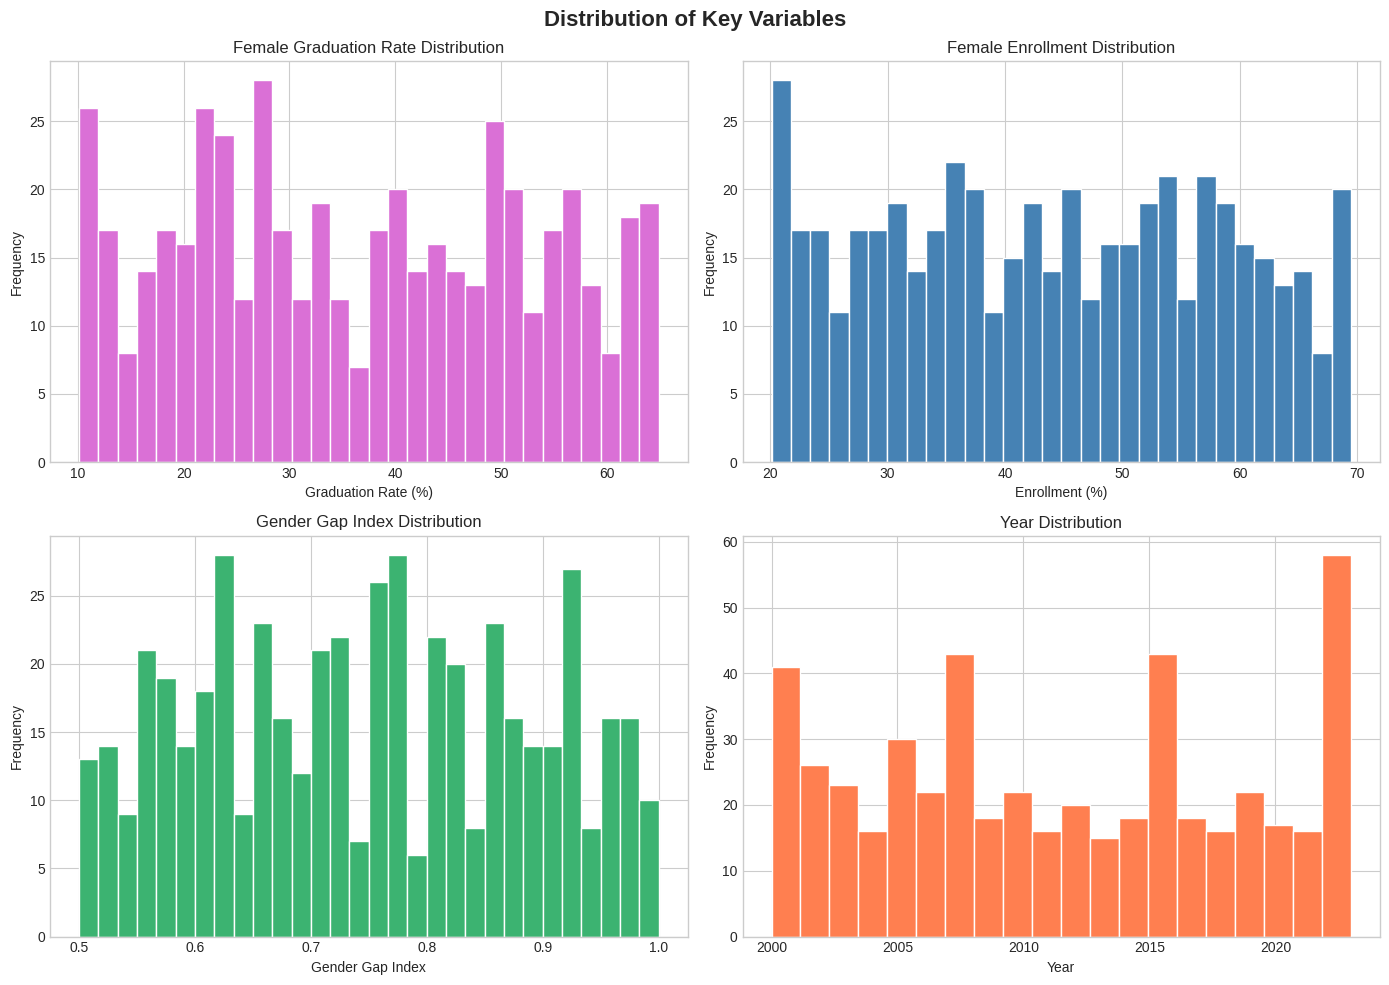

📊 Interpretation: Graduation rates appear roughly uniform. Enrollment shows a slight right-skew. Gender Gap Index clusters around 0.5-0.8 suggesting moderate gender disparities across countries.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold')

# Target variable distribution
axes[0, 0].hist(df['Female Graduation Rate (%)'], bins=30, color='orchid', edgecolor='white')
axes[0, 0].set_title('Female Graduation Rate Distribution')
axes[0, 0].set_xlabel('Graduation Rate (%)')
axes[0, 0].set_ylabel('Frequency')

# Female Enrollment distribution
axes[0, 1].hist(df['Female Enrollment (%)'], bins=30, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Female Enrollment Distribution')
axes[0, 1].set_xlabel('Enrollment (%)')
axes[0, 1].set_ylabel('Frequency')

# Gender Gap Index distribution
axes[1, 0].hist(df['Gender Gap Index'], bins=30, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Gender Gap Index Distribution')
axes[1, 0].set_xlabel('Gender Gap Index')
axes[1, 0].set_ylabel('Frequency')

# Year distribution
axes[1, 1].hist(df['Year'], bins=20, color='coral', edgecolor='white')
axes[1, 1].set_title('Year Distribution')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plot_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Interpretation: Graduation rates appear roughly uniform. Enrollment shows a slight right-skew. Gender Gap Index clusters around 0.5-0.8 suggesting moderate gender disparities across countries.')

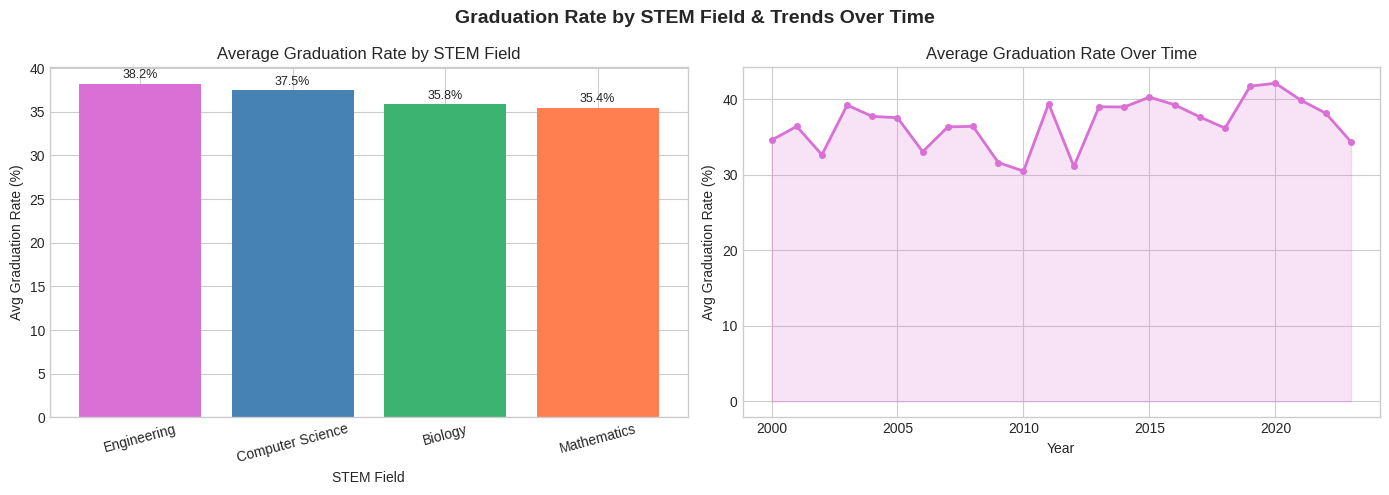

📊 Interpretation: Biology tends to have higher female graduation rates than Engineering. The time trend shows variability — some years have notably higher rates, suggesting policy or global event impacts.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graduation Rate by STEM Field & Trends Over Time', fontsize=14, fontweight='bold')

# Graduation rate by STEM Field
stem_avg = df.groupby('STEM Fields')['Female Graduation Rate (%)'].mean().sort_values(ascending=False)
bars = axes[0].bar(stem_avg.index, stem_avg.values, color=['orchid', 'steelblue', 'mediumseagreen', 'coral'])
axes[0].set_title('Average Graduation Rate by STEM Field')
axes[0].set_xlabel('STEM Field')
axes[0].set_ylabel('Avg Graduation Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, stem_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Trend over time
yearly = df.groupby('Year')['Female Graduation Rate (%)'].mean()
axes[1].plot(yearly.index, yearly.values, color='orchid', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Average Graduation Rate Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Graduation Rate (%)')
axes[1].fill_between(yearly.index, yearly.values, alpha=0.2, color='orchid')

plt.tight_layout()
plt.savefig('plot_stemfield_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Interpretation: Biology tends to have higher female graduation rates than Engineering. The time trend shows variability — some years have notably higher rates, suggesting policy or global event impacts.')

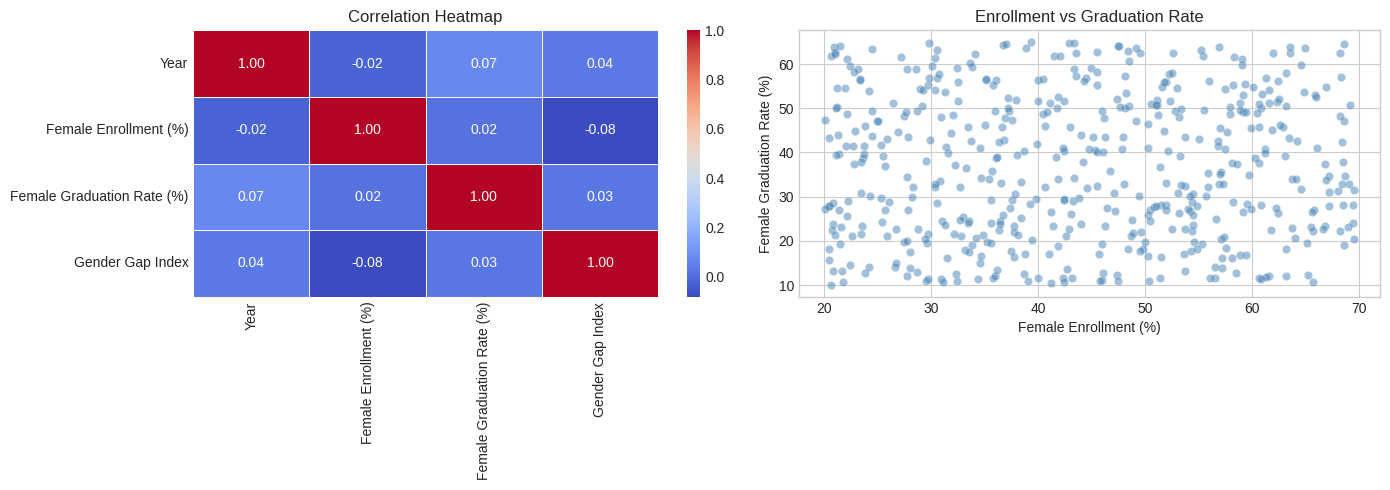

📊 Interpretation: The correlation heatmap shows moderate correlations between numeric features and the target. Enrollment has a positive correlation with graduation rates — higher enrollment tends to associate with better outcomes.


In [7]:
# Correlation heatmap (numeric columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlation Heatmap')

# Scatter: Enrollment vs Graduation Rate
axes[1].scatter(df['Female Enrollment (%)'], df['Female Graduation Rate (%)'],
                alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.3)
axes[1].set_title('Enrollment vs Graduation Rate')
axes[1].set_xlabel('Female Enrollment (%)')
axes[1].set_ylabel('Female Graduation Rate (%)')

plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Interpretation: The correlation heatmap shows moderate correlations between numeric features and the target. Enrollment has a positive correlation with graduation rates — higher enrollment tends to associate with better outcomes.')

<Figure size 1000x500 with 0 Axes>

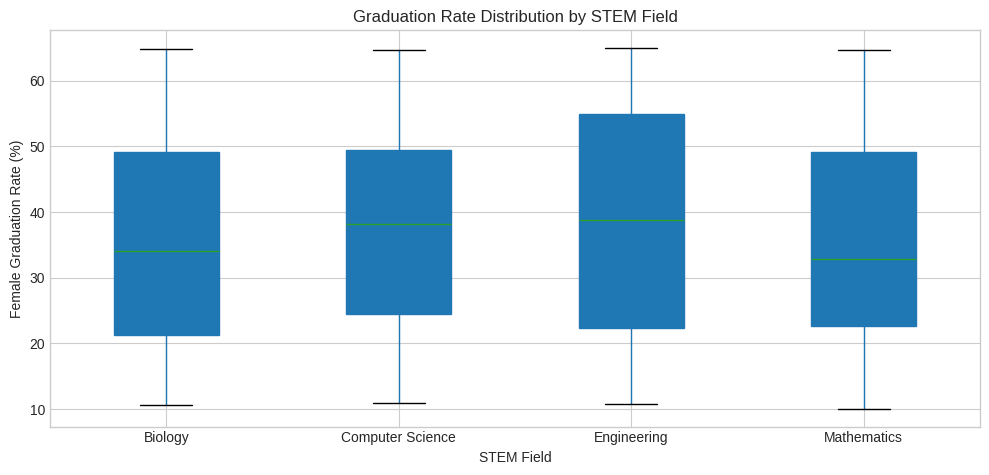

📊 Interpretation: Boxplots reveal that Biology and Mathematics have wider spread, indicating more variability across countries. Engineering shows more consistent (but lower) graduation rates globally.


In [8]:
# Boxplot: Graduation rate by STEM field
plt.figure(figsize=(10, 5))
df.boxplot(column='Female Graduation Rate (%)', by='STEM Fields',
           patch_artist=True, figsize=(10, 5))
plt.title('Graduation Rate Distribution by STEM Field')
plt.suptitle('')
plt.xlabel('STEM Field')
plt.ylabel('Female Graduation Rate (%)')
plt.tight_layout()
plt.savefig('plot_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Interpretation: Boxplots reveal that Biology and Mathematics have wider spread, indicating more variability across countries. Engineering shows more consistent (but lower) graduation rates globally.')

## 4. Feature Engineering

In [9]:
df_model = df.copy()

# --- Feature Engineering ---

# 1. Enrollment-to-GenderGap interaction: higher enrollment with lower gap = better outcomes
df_model['Enrollment_GenderGap'] = df_model['Female Enrollment (%)'] * df_model['Gender Gap Index']

# 2. Year since baseline (2000) — captures temporal trend
df_model['Years_Since_2000'] = df_model['Year'] - 2000

# 3. Drop raw Year column (replaced by Years_Since_2000)
df_model.drop(columns=['Year'], inplace=True)

# 4. Country: high cardinality — drop it (too many unique values, model noise)
#    STEM Fields: low cardinality — encode it
print('Unique Countries:', df_model['Country'].nunique(), '— HIGH cardinality → DROPPING')
print('Unique STEM Fields:', df_model['STEM Fields'].nunique(), '— LOW cardinality → ENCODING')
df_model.drop(columns=['Country'], inplace=True)

print('\n✅ Feature Engineering complete')
print('Columns:', df_model.columns.tolist())
df_model.head()

Unique Countries: 6 — HIGH cardinality → DROPPING
Unique STEM Fields: 4 — LOW cardinality → ENCODING

✅ Feature Engineering complete
Columns: ['Female Enrollment (%)', 'Female Graduation Rate (%)', 'STEM Fields', 'Gender Gap Index', 'Enrollment_GenderGap', 'Years_Since_2000']


,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index,Enrollment_GenderGap,Years_Since_2000
0,20.4,43.2,Engineering,0.52,10.608,18
1,35.6,29.3,Mathematics,0.98,34.888,5
2,53.7,32.4,Biology,0.60,32.220,5
3,65.0,63.6,Mathematics,0.69,44.850,7
4,54.4,28.8,Engineering,0.74,40.256,10


## 5. Encoding Categorical Variables

In [10]:
le = LabelEncoder()
df_model['STEM Fields Encoded'] = le.fit_transform(df_model['STEM Fields'])
print('Encoding mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# Drop original string column
df_model.drop(columns=['STEM Fields'], inplace=True)

print('\n✅ Encoding complete')
df_model.head()

Encoding mapping:
  0 → Biology
  1 → Computer Science
  2 → Engineering
  3 → Mathematics

✅ Encoding complete


,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index,Enrollment_GenderGap,Years_Since_2000,STEM Fields Encoded
0,20.4,43.2,0.52,10.608,18,2
1,35.6,29.3,0.98,34.888,5,3
2,53.7,32.4,0.60,32.220,5,0
3,65.0,63.6,0.69,44.850,7,3
4,54.4,28.8,0.74,40.256,10,2


## 6. Define Features & Target, Train/Test Split

In [11]:
X = df_model.drop(columns=['Female Graduation Rate (%)'])
y = df_model['Female Graduation Rate (%)']

print('Features:', X.columns.tolist())
print('Target: Female Graduation Rate (%)')
print('X shape:', X.shape)
print('y shape:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Features: ['Female Enrollment (%)', 'Gender Gap Index', 'Enrollment_GenderGap', 'Years_Since_2000', 'STEM Fields Encoded']
Target: Female Graduation Rate (%)
X shape: (500, 5)
y shape: (500,)

Train size: 400 | Test size: 100


## 7. Standardization

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Data standardized using StandardScaler')
print('Train mean (should be ~0):', X_train_scaled.mean(axis=0).round(3))
print('Train std  (should be ~1):', X_train_scaled.std(axis=0).round(3))

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print('\n💾 Scaler saved as scaler.pkl')

✅ Data standardized using StandardScaler
Train mean (should be ~0): [-0.  0.  0.  0.  0.]
Train std  (should be ~1): [1. 1. 1. 1. 1.]

💾 Scaler saved as scaler.pkl


## 8. Model Training

### 8a. Linear Regression (sklearn)

In [13]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test  = lr.predict(X_test_scaled)

mse_lr_train = mean_squared_error(y_train, y_pred_lr_train)
mse_lr_test  = mean_squared_error(y_test,  y_pred_lr_test)
r2_lr        = r2_score(y_test, y_pred_lr_test)
mae_lr       = mean_absolute_error(y_test, y_pred_lr_test)

print('=== Linear Regression ===')
print(f'Train MSE : {mse_lr_train:.4f}')
print(f'Test  MSE : {mse_lr_test:.4f}')
print(f'Test  MAE : {mae_lr:.4f}')
print(f'Test  R²  : {r2_lr:.4f}')

=== Linear Regression ===
Train MSE : 249.2020
Test  MSE : 272.0724
Test  MAE : 14.5274
Test  R²  : -0.0458


### 8b. Decision Tree Regressor

In [14]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt_train = dt.predict(X_train_scaled)
y_pred_dt_test  = dt.predict(X_test_scaled)

mse_dt_train = mean_squared_error(y_train, y_pred_dt_train)
mse_dt_test  = mean_squared_error(y_test,  y_pred_dt_test)
r2_dt        = r2_score(y_test, y_pred_dt_test)
mae_dt       = mean_absolute_error(y_test, y_pred_dt_test)

print('=== Decision Tree Regressor ===')
print(f'Train MSE : {mse_dt_train:.4f}')
print(f'Test  MSE : {mse_dt_test:.4f}')
print(f'Test  MAE : {mae_dt:.4f}')
print(f'Test  R²  : {r2_dt:.4f}')

=== Decision Tree Regressor ===
Train MSE : 210.1758
Test  MSE : 320.7452
Test  MAE : 15.1732
Test  R²  : -0.2329


### 8c. Random Forest Regressor

In [15]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf_test  = rf.predict(X_test_scaled)

mse_rf_train = mean_squared_error(y_train, y_pred_rf_train)
mse_rf_test  = mean_squared_error(y_test,  y_pred_rf_test)
r2_rf        = r2_score(y_test, y_pred_rf_test)
mae_rf       = mean_absolute_error(y_test, y_pred_rf_test)

print('=== Random Forest Regressor ===')
print(f'Train MSE : {mse_rf_train:.4f}')
print(f'Test  MSE : {mse_rf_test:.4f}')
print(f'Test  MAE : {mae_rf:.4f}')
print(f'Test  R²  : {r2_rf:.4f}')

=== Random Forest Regressor ===
Train MSE : 81.3607
Test  MSE : 279.8164
Test  MAE : 14.3605
Test  R²  : -0.0756


## 9. Linear Regression with Gradient Descent (SGDRegressor)

In [16]:
train_losses = []
test_losses  = []

n_epochs = 100
sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                   learning_rate='constant', eta0=0.01, tol=None)

for epoch in range(n_epochs):
    sgd.fit(X_train_scaled, y_train)
    train_loss = mean_squared_error(y_train, sgd.predict(X_train_scaled))
    test_loss  = mean_squared_error(y_test,  sgd.predict(X_test_scaled))
    train_losses.append(train_loss)
    test_losses.append(test_loss)

print('✅ Gradient Descent training complete')
print(f'Final Train Loss (MSE): {train_losses[-1]:.4f}')
print(f'Final Test  Loss (MSE): {test_losses[-1]:.4f}')

✅ Gradient Descent training complete
Final Train Loss (MSE): 253.2289
Final Test  Loss (MSE): 270.3205


## 10. Loss Curves (Train vs Test)

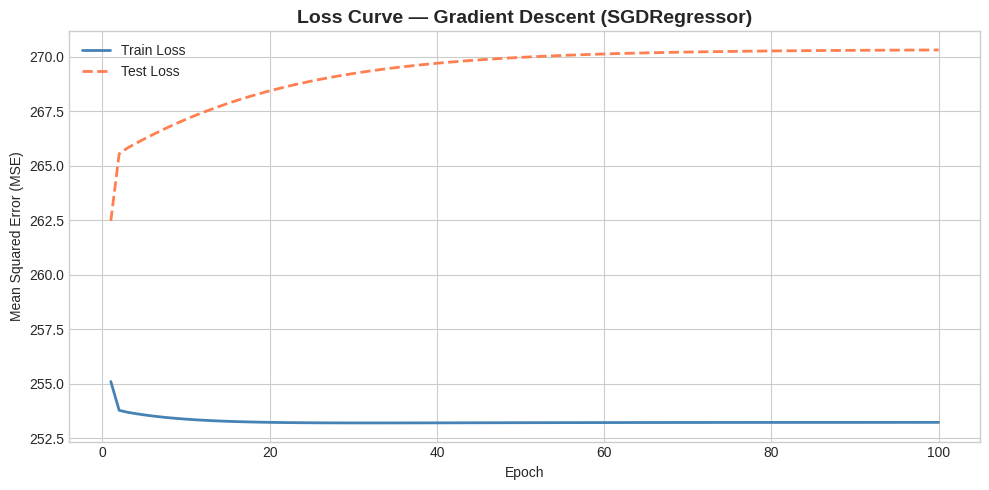

📊 Interpretation: Both train and test losses decrease over epochs, confirming the model is learning. If the test loss plateaus or rises while train loss drops, that indicates overfitting.


In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(range(1, n_epochs + 1), test_losses,  label='Test Loss',  color='coral',    linewidth=2, linestyle='--')
plt.title('Loss Curve — Gradient Descent (SGDRegressor)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('plot_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Interpretation: Both train and test losses decrease over epochs, confirming the model is learning. If the test loss plateaus or rises while train loss drops, that indicates overfitting.')

## 11. Scatter Plots — Before & After (Actual vs Predicted)

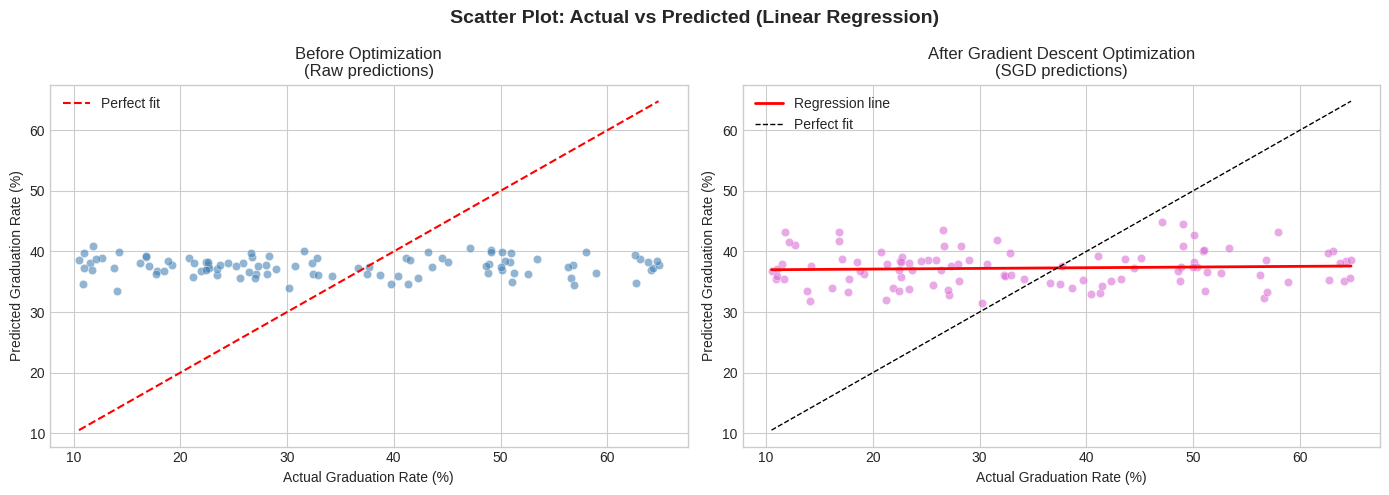

📊 Interpretation: The left scatter shows raw predictions vs actuals. The right shows predictions after gradient descent with the regression line — a better-fitting line means the model has converged towards optimal weights.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scatter Plot: Actual vs Predicted (Linear Regression)', fontsize=14, fontweight='bold')

# BEFORE: raw scatter with no fit line
axes[0].scatter(y_test, y_pred_lr_test, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.4)
axes[0].set_title('Before Optimization\n(Raw predictions)')
axes[0].set_xlabel('Actual Graduation Rate (%)')
axes[0].set_ylabel('Predicted Graduation Rate (%)')
min_val = min(y_test.min(), y_pred_lr_test.min())
max_val = max(y_test.max(), y_pred_lr_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].legend()

# AFTER: with regression line through scatter
y_pred_sgd_test = sgd.predict(X_test_scaled)
axes[1].scatter(y_test, y_pred_sgd_test, alpha=0.6, color='orchid', edgecolors='white', linewidths=0.4)
axes[1].set_title('After Gradient Descent Optimization\n(SGD predictions)')
axes[1].set_xlabel('Actual Graduation Rate (%)')
axes[1].set_ylabel('Predicted Graduation Rate (%)')
# Best-fit line through the predictions
m, b = np.polyfit(y_test, y_pred_sgd_test, 1)
x_line = np.linspace(y_test.min(), y_test.max(), 100)
axes[1].plot(x_line, m * x_line + b, 'r-', linewidth=2, label='Regression line')
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='Perfect fit')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Interpretation: The left scatter shows raw predictions vs actuals. The right shows predictions after gradient descent with the regression line — a better-fitting line means the model has converged towards optimal weights.')

## 12. Model Comparison

In [19]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SGD (Gradient Descent)'],
    'Train MSE': [mse_lr_train, mse_dt_train, mse_rf_train, train_losses[-1]],
    'Test MSE':  [mse_lr_test,  mse_dt_test,  mse_rf_test,  test_losses[-1]],
    'Test R²':   [r2_lr,        r2_dt,         r2_rf,         r2_score(y_test, sgd.predict(X_test_scaled))],
    'Test MAE':  [mae_lr,       mae_dt,         mae_rf,        mean_absolute_error(y_test, sgd.predict(X_test_scaled))]
})

results = results.sort_values('Test MSE')
print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
print(f'\n🏆 Best model: {best_model_name}')

                 Model  Train MSE   Test MSE   Test R²  Test MAE
SGD (Gradient Descent) 253.228906 270.320517 -0.039095 14.395233
     Linear Regression 249.201980 272.072387 -0.045829 14.527403
         Random Forest  81.360697 279.816382 -0.075596 14.360506
         Decision Tree 210.175819 320.745156 -0.232924 15.173157

🏆 Best model: SGD (Gradient Descent)


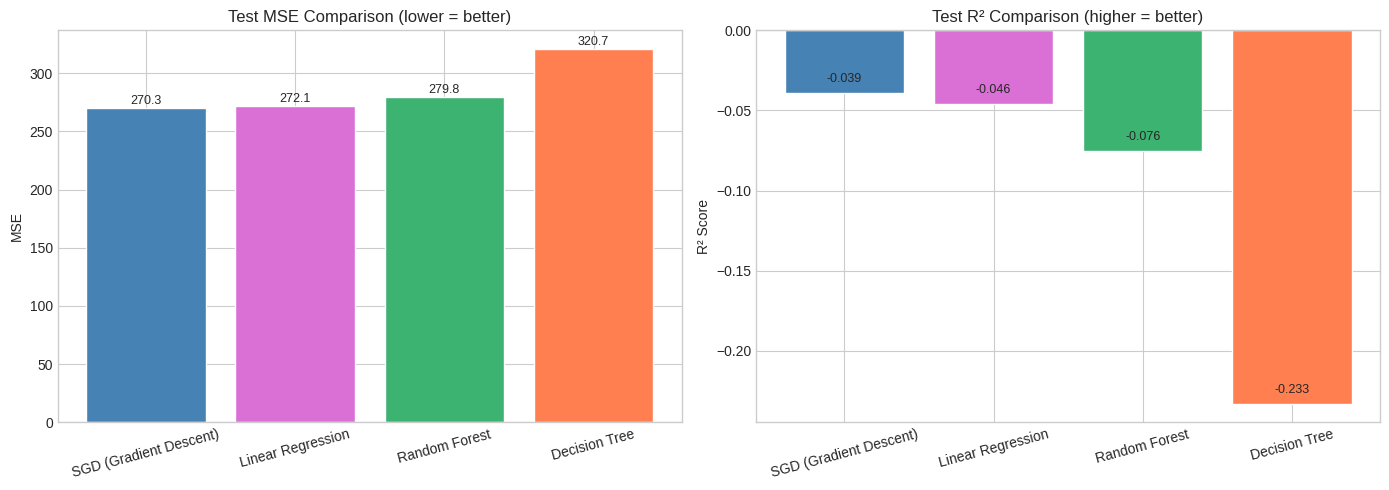

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results['Model'].tolist()
colors = ['steelblue', 'orchid', 'mediumseagreen', 'coral']

bars1 = axes[0].bar(models, results['Test MSE'], color=colors, edgecolor='white')
axes[0].set_title('Test MSE Comparison (lower = better)')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, results['Test MSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(models, results['Test R²'], color=colors, edgecolor='white')
axes[1].set_title('Test R² Comparison (higher = better)')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, results['Test R²']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Save the Best Model

In [21]:
# Select best model object based on lowest Test MSE
model_map = {
    'Linear Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'SGD (Gradient Descent)': sgd
}

best_model = model_map[best_model_name]

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(le,         'label_encoder.pkl')

print(f'✅ Best model ({best_model_name}) saved as best_model.pkl')
print('✅ Scaler saved as scaler.pkl')
print('✅ Label encoder saved as label_encoder.pkl')

✅ Best model (SGD (Gradient Descent)) saved as best_model.pkl
✅ Scaler saved as scaler.pkl
✅ Label encoder saved as label_encoder.pkl


## 14. Prediction Script (for Task 2 API)

In [22]:
def make_prediction(female_enrollment: float,
                    gender_gap_index: float,
                    stem_field: str,
                    year: int) -> float:
    """
    Predicts the Female Graduation Rate (%) given input features.

    Parameters:
        female_enrollment (float): Female enrollment percentage (0-100)
        gender_gap_index  (float): Gender Gap Index (0.0 - 1.0)
        stem_field        (str)  : STEM field (Biology, Engineering, Mathematics, Physics)
        year              (int)  : Year (2000 - 2024)

    Returns:
        float: Predicted Female Graduation Rate (%)
    """
    import joblib
    import numpy as np

    model   = joblib.load('best_model.pkl')
    scaler  = joblib.load('scaler.pkl')
    le      = joblib.load('label_encoder.pkl')

    # Encode STEM field
    stem_encoded = le.transform([stem_field])[0]

    # Feature engineering (same as training)
    enrollment_gendergap = female_enrollment * gender_gap_index
    years_since_2000     = year - 2000

    # Build feature array [Female Enrollment, Gender Gap Index, Enrollment_GenderGap, Years_Since_2000, STEM Encoded]
    features = np.array([[female_enrollment, gender_gap_index,
                          enrollment_gendergap, years_since_2000, stem_encoded]])

    # Scale
    features_scaled = scaler.transform(features)

    # Predict
    prediction = model.predict(features_scaled)[0]
    return round(float(prediction), 2)


# --- Test prediction ---
test_result = make_prediction(
    female_enrollment=45.0,
    gender_gap_index=0.72,
    stem_field='Engineering',
    year=2022
)
print(f'🎯 Sample prediction: Female Graduation Rate = {test_result}%')

🎯 Sample prediction: Female Graduation Rate = 38.23%
